In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
titanic = sns.load_dataset('titanic')

In [5]:
titanic.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
339,0,1,male,45.0,0,0,35.500,S,First,man,True,NaN,Southampton,no,True
543,1,2,male,32.0,1,0,26.000,S,Second,man,True,NaN,Southampton,yes,False
344,0,2,male,36.0,0,0,13.000,S,Second,man,True,NaN,Southampton,no,True
333,0,3,male,16.0,2,0,18.000,S,Third,man,True,NaN,Southampton,no,False
380,1,1,female,42.0,0,0,227.525,C,First,woman,False,NaN,Cherbourg,yes,True


In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
titanic.isna().sum()


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


 و ال age
عمود deck سيتم حذفه

In [52]:
titanic = titanic.dropna(subset=['age'])


In [53]:
titanic["sex"].unique()



array(['male', 'female'], dtype=object)

In [8]:
titanic.drop("deck", axis=1, inplace=True)



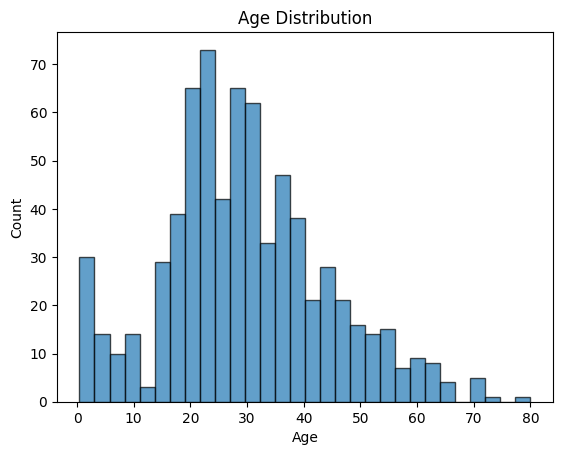

In [19]:
#توزيع الاعمار
plt.hist(titanic["age"], bins=30, edgecolor='black', alpha=0.7)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


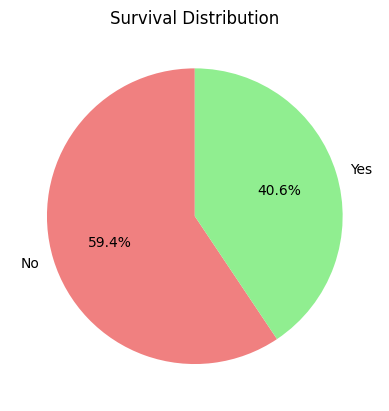

In [76]:
titanic.loc[:, 'survived_label'] = titanic['survived'].map({0: 'No', 1: 'Yes'})

titanic['survived_label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    labels=['No', 'Yes'],
    colors=['lightcoral', 'lightgreen']
)

plt.title("Survival Distribution")
plt.ylabel("")
plt.show()

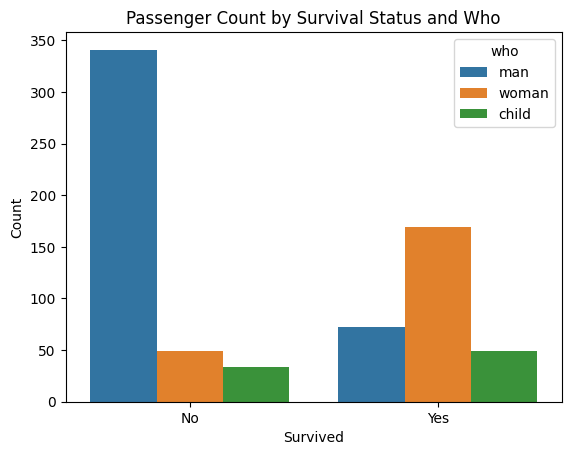

In [68]:
titanic.loc[:, 'survived_label'] = titanic['survived'].map({0: 'No', 1: 'Yes'})
sns.countplot(data=titanic, x='survived_label', hue='who')
plt.title('Passenger Count by Survival Status and Who')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()


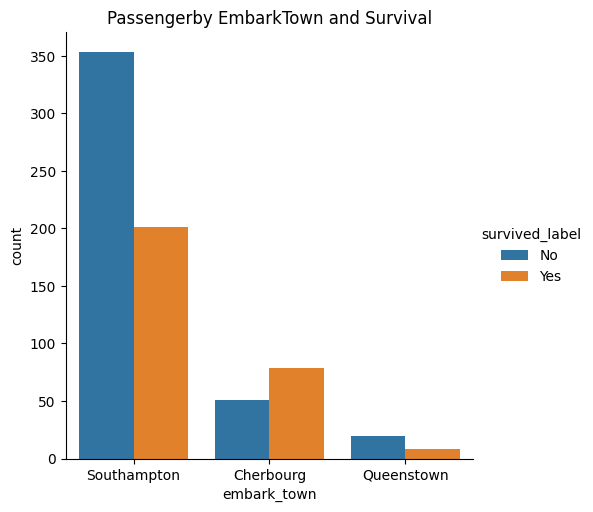

In [70]:
sns.catplot(data=titanic, x='embark_town', hue='survived_label', kind='count')
plt.title('Passengerby EmbarkTown and Survival')
plt.show()


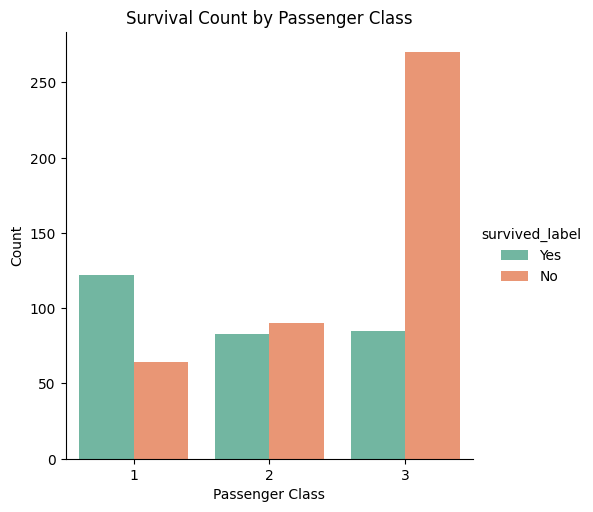

In [71]:
sns.catplot(data=titanic, x='pclass', hue='survived_label', kind='count', palette='Set2')
plt.title('Survival Count by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.show()


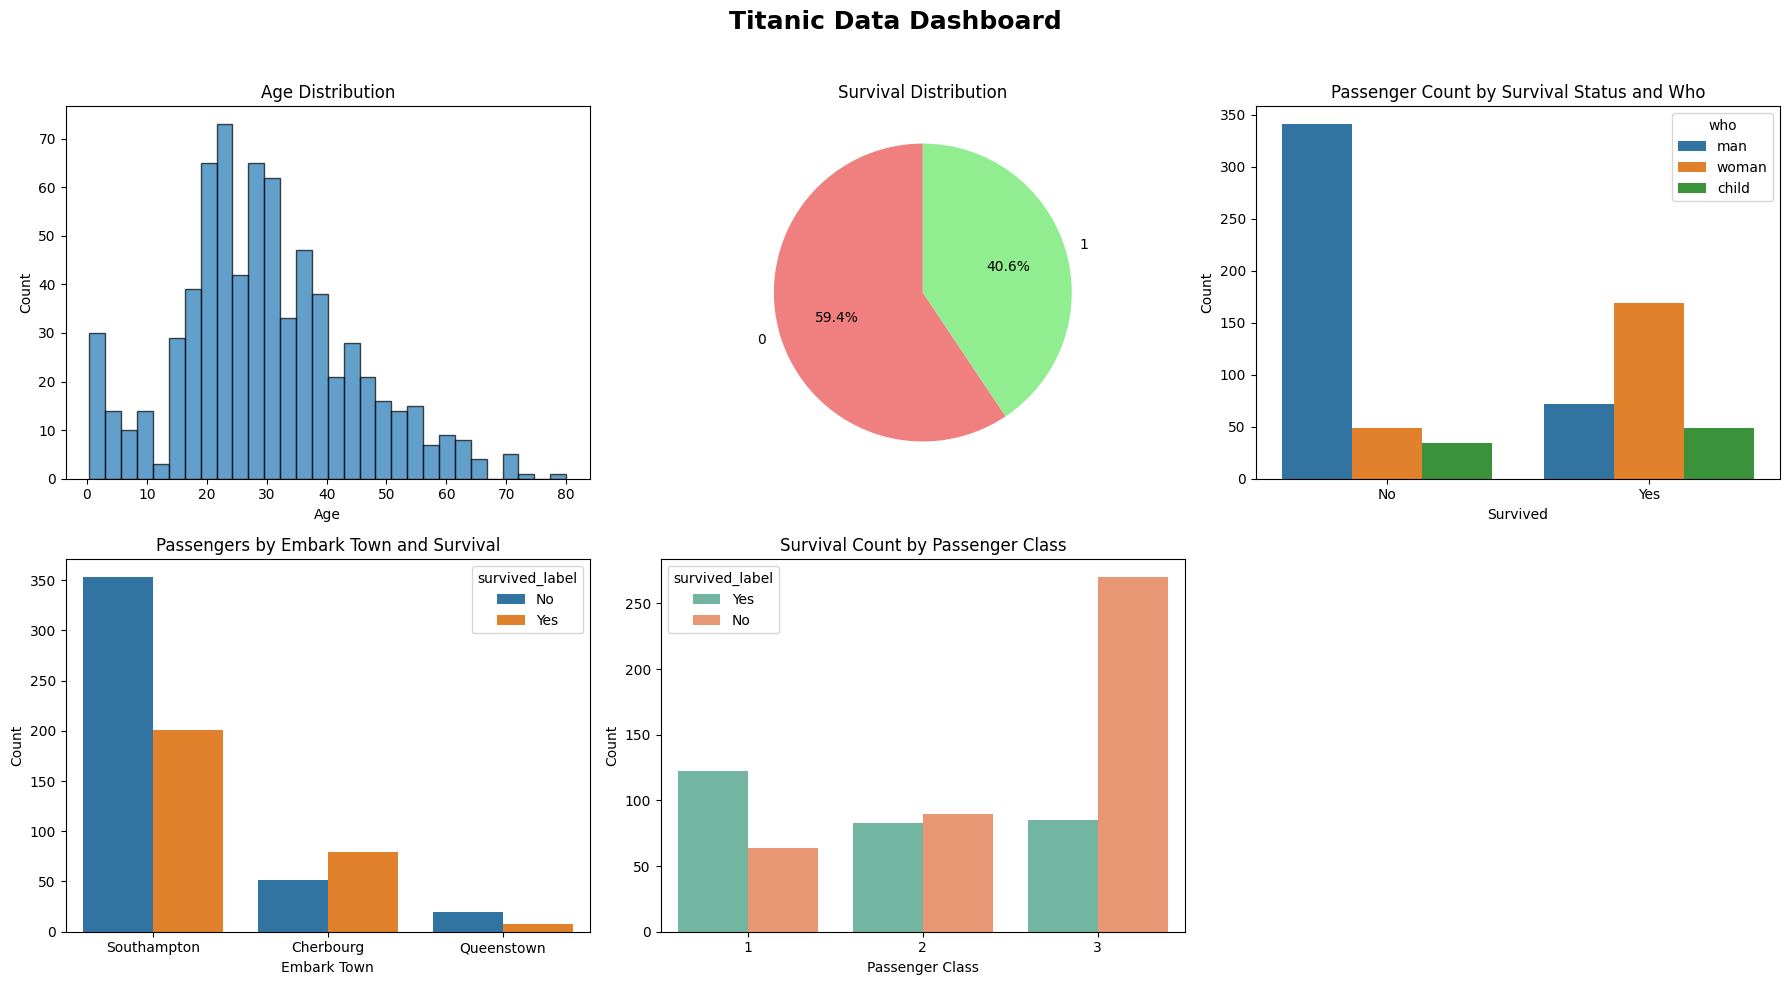

In [80]:



fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Titanic Data Dashboard", fontsize=18, fontweight='bold')


axes[0, 0].hist(titanic["age"], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

titanic['survived'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, ax=axes[0, 1], colors=['lightcoral', 'lightgreen'])
axes[0, 1].set_title("Survival Distribution")
axes[0, 1].set_ylabel("")

sns.countplot(data=titanic, x='survived_label', hue='who', ax=axes[0, 2])
axes[0, 2].set_title('Passenger Count by Survival Status and Who')
axes[0, 2].set_xlabel('Survived')
axes[0, 2].set_ylabel('Count')


sns.countplot(data=titanic, x='embark_town', hue='survived_label', ax=axes[1, 0])
axes[1, 0].set_title('Passengers by Embark Town and Survival')
axes[1, 0].set_xlabel('Embark Town')
axes[1, 0].set_ylabel('Count')


sns.countplot(data=titanic, x='pclass', hue='survived_label', palette='Set2', ax=axes[1, 1])
axes[1, 1].set_title('Survival Count by Passenger Class')
axes[1, 1].set_xlabel('Passenger Class')
axes[1, 1].set_ylabel('Count')

axes[1, 2].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
